Week 6 – Classification Algorithms
Day 1: Setup + Decision Tree Classifier
Dataset: Pima Indians Diabetes (binary classification – diabetic or not) Goal: Build ML workflow — split → train → predict → evaluate, starting with a Decision Tree.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              roc_curve, roc_auc_score)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
np.random.seed(42)

Load and Explore the Diabetes Dataset

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)
print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
print("Class balance (Outcome):")
print(df["Outcome"].value_counts())
print(f"\nPositive (diabetic) rate: {df['Outcome'].mean():.1%}")
print("\nThe dataset is moderately imbalanced (~65% / 35%), which is why we look at")
print("precision/recall/F1 in addition to accuracy, not accuracy alone.")

Class balance (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64

Positive (diabetic) rate: 34.9%

The dataset is moderately imbalanced (~65% / 35%), which is why we look at
precision/recall/F1 in addition to accuracy, not accuracy alone.


1.1 A data-quality catch: hidden missing values

In [6]:
cols_with_invalid_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols_with_invalid_zero:
    zero_count = (df[col] == 0).sum()
    print(f"{col:15s}: {zero_count:4d} rows with value 0 ({zero_count/len(df):.1%})")

Glucose        :    5 rows with value 0 (0.7%)
BloodPressure  :   35 rows with value 0 (4.6%)
SkinThickness  :  227 rows with value 0 (29.6%)
Insulin        :  374 rows with value 0 (48.7%)
BMI            :   11 rows with value 0 (1.4%)


Visual EDA

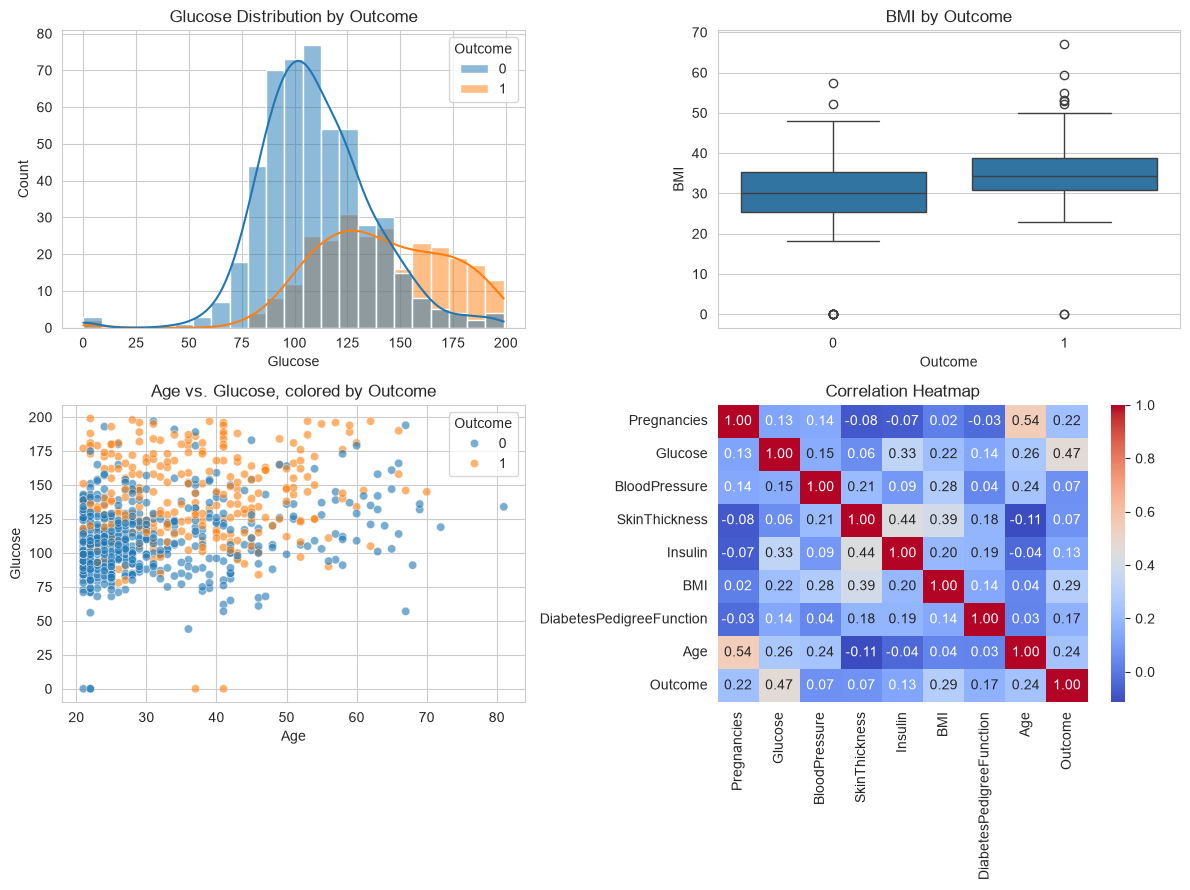

Glucose shows the clearest separation between outcomes -- expected, since it's the most
direct clinical indicator of diabetes.


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.histplot(data=df, x="Glucose", hue="Outcome", kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Glucose Distribution by Outcome")

sns.boxplot(data=df, x="Outcome", y="BMI", ax=axes[0, 1])
axes[0, 1].set_title("BMI by Outcome")

sns.scatterplot(data=df, x="Age", y="Glucose", hue="Outcome", alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title("Age vs. Glucose, colored by Outcome")

corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

print("Glucose shows the clearest separation between outcomes -- expected, since it's the most")
print("direct clinical indicator of diabetes.")

Part 2 — Cleaning: Fixing the Hidden Zeros

In [10]:
df_clean = df.copy()

for col in cols_with_invalid_zero:
    df_clean[col] = df_clean[col].replace(0, np.nan)

# Impute per-class median so the imputation doesn't blur the signal between classes
for col in cols_with_invalid_zero:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values after cleaning:")
print(df_clean.isnull().sum().sum())
df_clean.head()

Remaining missing values after cleaning:
0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
